# TODO

- Every image with sensors or predictions show the paris region borders

- Create plots with the simulation predictions similar to the ones in the final report for each pollutant.
- Create plots with the augmented distributions


In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import imageio.v2 as imageio
from matplotlib.gridspec import GridSpec

from src.utils.visualization import *
from src.utils.visualization import _add_aligned_colorbar
from PIL import Image
from IPython.display import HTML

from src.datasets.vitae_dataset import load_data as load_vitae
from src.datasets.voronoi_datasets import load_data as load_voronoi
from src.datasets.utils import read_real_observation_files

save_dir = "paper_images"
os.makedirs(save_dir, exist_ok=True)

background_paris = np.load("data/map_rgb_adjusted.npy")

In [3]:
timesteps = [1, 2, 3, 4, 6, 8, 12]

vunet_results = [
    np.load('paper_results/predictions/vunet/t1_42_results.npz'),
    np.load('paper_results/predictions/vunet/t2_42_results.npz'),
    np.load('paper_results/predictions/vunet/t3_42_results.npz'),
    np.load('paper_results/predictions/vunet/t4_42_results.npz'),
    np.load('paper_results/predictions/vunet/t6_42_results.npz'),
    np.load('paper_results/predictions/vunet/t8_42_results.npz'),
    np.load('paper_results/predictions/vunet/t12_42_results.npz')
]


clstm_results = [
    np.load('paper_results/predictions/clstm/t1_42_results.npz'),
    np.load('paper_results/predictions/clstm/t2_42_results.npz'),
    np.load('paper_results/predictions/clstm/t3_42_results.npz'),
    np.load('paper_results/predictions/clstm/t4_42_results.npz'),
    np.load('paper_results/predictions/clstm/t6_42_results.npz'),
    np.load('paper_results/predictions/clstm/t8_42_results.npz'),
    np.load('paper_results/predictions/clstm/t12_42_results.npz')
]

vitae_results = [
    np.load('paper_results/predictions/vitae/t1_results.npz'),
    np.load('paper_results/predictions/vitae/t2_results.npz'),
    np.load('paper_results/predictions/vitae/t3_results.npz'),
    np.load('paper_results/predictions/vitae/t4_results.npz'),
    np.load('paper_results/predictions/vitae/t6_results.npz'),
    np.load('paper_results/predictions/vitae/t8_results.npz'),
    np.load('paper_results/predictions/vitae/t12_results.npz')
]

diffusion_results = [
    np.load('paper_results/predictions/diffusion/short_training_results.npz')
]

kriging_results = [
    np.load('paper_results/predictions/kriging/kriging_paper_fixed_results.npz')
]

all_results = [
    ("vunet", vunet_results),
    ("clstm", clstm_results),
    ("vitae", vitae_results),
    ("diffusion", diffusion_results),
    ("kriging", kriging_results)
]

In [6]:
for model_name, results in all_results:
    for t, result in zip(timesteps, results):

        print("Model:", model_name, "Timesteps:", t)

        for file in result.files:
            if "global" in file.lower() or "pollutants" in file.lower():
                if file == 'simulated_global_ssim':
                    print(f"{file}: {np.mean(result['simulated_pollutants_ssim'])}")
                else:
                    print(f"{file}: {result[file]}")

        if model_name == "vitae":
            from src.utils.evaluation_pipeline import compute_simulated_metrics
            sim_metrics = compute_simulated_metrics(
                torch.from_numpy(result['simulated_observations']), 
                torch.from_numpy(result['simulated_ground_truths']), 
                torch.from_numpy(result['simulated_predictions']),
                pollutant_type='all'
                )
            print("simulated_global_ssim:", np.mean(sim_metrics['pollutants_ssim']))
            print("simulated_pollutants_ssim:", sim_metrics['pollutants_ssim'])

        print()

    print("-" * 40)

Model: vunet Timesteps: 1
simulated_global_re: 0.11850814138394428
simulated_pollutants_re: [0.09561078 0.20657132 0.21296067 0.26192422]
simulated_global_rmse: 3.8836058773966933
simulated_pollutants_rmse: [5.54616368 2.7902739  2.47780782 3.95531121]
simulated_global_rrmse: 0.12207980926749348
simulated_pollutants_rrmse: [0.092224   0.24254293 0.23955599 0.28536641]
simulated_global_mfe: 0.1781757932757606
simulated_pollutants_mfe: [0.08109895 0.16679556 0.17259478 0.29221388]
simulated_global_mfb: -0.009531280808642796
simulated_pollutants_mfb: [-0.02148789 -0.05771061 -0.08795786  0.12903124]
simulated_global_ssim: 0.6693752408027649
simulated_pollutants_ssim: [0.5967923  0.6430994  0.5989974  0.83861184]
real_global_re: 0.2877012088263099
real_pollutants_re: [1.51140758 0.33128491 0.36857778 0.25869958]
real_global_rmse: 9.343409447016617
real_pollutants_rmse: [11.18809818  8.06984672  4.57425197 11.74257727]
real_global_rrmse: 0.305306257619954
real_pollutants_rrmse: [0.314984   

In [4]:
from src.utils.evaluation import compute_relative_error, compute_rmse, compute_rrmse, compute_mean_fractional_error, compute_mean_fractional_bias, compute_SSIM

polutant_order = ["O3", "PM10", "PM2.5", "NO2"]

df_results = []
for model_name, results in all_results:
    for t, result in zip(timesteps, results):
        entry = {
            "model": model_name,
            "timestep": t,
        }

        for file in result.files:
            if "global" in file.lower():
                entry.update({
                    file.lower(): result[file].item()
                })
            elif "pollutants" in file.lower():
                for i, polutant in enumerate(polutant_order):
                    entry.update({
                        f"{file.lower().replace("pollutants", polutant)}": result[file][i]
                    })

        if model_name == "vitae":
            entry["simulated_global_ssim"] = np.mean(compute_SSIM(
                torch.tensor(result["simulated_ground_truths"]).numpy(),
                torch.tensor(result["simulated_predictions"]).numpy()
            ))
        
        df_results.append(entry)

df = pd.DataFrame(df_results)

no_diffusion_df = df[df["model"] != "diffusion"]

In [5]:
df[df['model'] == 'vitae'].head(25)['simulated_global_ssim']

14    0.815356
15    0.843466
16    0.828001
17    0.829277
18    0.840344
19    0.839206
20    0.837386
Name: simulated_global_ssim, dtype: float64

In [ ]:
"""
TODO:
    - Wait for the SSIM to be ready.
    - 
"""

fig = plt.figure(figsize=(8, 6.5))

# OUTER grid: 2 rows, 1 column
gs_outer = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.5, figure=fig)

# ─────────────────────────────────────────────────────
# TOP ROW: 2 columns with WIDE spacing
# ─────────────────────────────────────────────────────
gs_top = gs_outer[0].subgridspec(
    1, 2,
    wspace=0.35
)

ax_top_left  = fig.add_subplot(gs_top[0, 0])
ax_top_right = fig.add_subplot(gs_top[0, 1])

# ─────────────────────────────────────────────────────
# BOTTOM ROW: 4 columns with TIGHT spacing
# ─────────────────────────────────────────────────────
gs_bottom = gs_outer[1].subgridspec(
    1, 4,
    wspace=0.05
)

ax_b1 = fig.add_subplot(gs_bottom[0, 0])
ax_b2 = fig.add_subplot(gs_bottom[0, 1])
ax_b3 = fig.add_subplot(gs_bottom[0, 2])
ax_b4 = fig.add_subplot(gs_bottom[0, 3])

fig.text(
    0.5,
    0.35,
    "Best Performing Model Reconstructions",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)

# --- Seaborn plots in the top two panels ---
sns.lineplot(data=no_diffusion_df, x="timestep", y="simulated_global_re", hue="model", style="model", ax=ax_top_left, markers=True)
sns.lineplot(data=no_diffusion_df, x="timestep", y="simulated_global_ssim", hue="model", style="model", ax=ax_top_right, markers=True)
ax_top_left.grid(linestyle="--", linewidth=0.8)
ax_top_right.grid(linestyle="--", linewidth=0.8)

ax_top_left.set_xlabel("Prediction Window Length (hours)")
ax_top_left.set_ylabel("Global Relative Error (RE)")
ax_top_left.set_title("Relative Error Across Timesteps")

ax_top_right.set_xlabel("Prediction Window Length (hours)")
ax_top_right.set_ylabel("Global Structural Similarity (SSIM)")
ax_top_right.set_title("SSIM Across Timesteps")

# --- Bottom panels with the best reconstruction ---

ax_b1.imshow(clstm_results[-1]["simulated_predictions"][5][0])
ax_b1.set_title("O3")
ax_b2.imshow(clstm_results[-1]["simulated_predictions"][5][1])
ax_b2.set_title("PM10")
ax_b3.imshow(clstm_results[-1]["simulated_predictions"][5][2])
ax_b3.set_title("PM2.5")
ax_b4.imshow(clstm_results[-1]["simulated_predictions"][5][3])
ax_b4.set_title("NO2")

# --- Styling to match your example layout ---
for ax in [ax_top_left, ax_top_right, ax_b1, ax_b2, ax_b3, ax_b4]:
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Remove ticks in the bottom row
for ax in [ax_b1, ax_b2, ax_b3, ax_b4]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

fig.tight_layout()
os.makedirs("paper_images/results", exist_ok=True)
plt.savefig("paper_images/results/deterministic.png", dpi=300)
plt.show()
plt.close()

In [7]:
diffusion_ensemble = [
    (np.load('paper_results/predictions/diffusion/ensemble/inf_2_results.npz'), 2),
    (np.load('paper_results/predictions/diffusion/ensemble/inf_5_results.npz'), 5),
    (np.load('paper_results/predictions/diffusion/ensemble/inf_10_results.npz'), 10),
    (np.load('paper_results/predictions/diffusion/ensemble/inf_15_results.npz'), 15),
    (np.load('paper_results/predictions/diffusion/ensemble/inf_20_results.npz'), 20),
    (np.load('paper_results/predictions/diffusion/ensemble/inf_40_results.npz'), 40)
]

tracked_metrics = ["simulated_global_ssim", "simulated_global_re", "simulated_global_rmse", "simulated_global_rrmse", "simulated_global_mfe", "simulated_global_mfb"]

ensemble_df_results = []
for result, num_steps in diffusion_ensemble:
    for ensemble_size in range(1, 21):
        entry = {
            "inference_steps": num_steps,
            "ensemble_size": ensemble_size,
        }

        for metric in tracked_metrics:
            entry[metric] = result[metric][ensemble_size - 1]

        ensemble_df_results.append(entry)

ensemble_df = pd.DataFrame(ensemble_df_results)

ensemble_df.head()

,inference_steps,ensemble_size,simulated_global_ssim,simulated_global_re,simulated_global_rmse,simulated_global_rrmse,simulated_global_mfe,simulated_global_mfb
0,2,1,0.868750,0.106270,3.516352,0.110535,0.138945,-0.003949
1,2,2,0.870324,0.106095,3.511980,0.110398,0.138643,-0.003992
2,2,3,0.870852,0.106034,3.510427,0.110349,0.138520,-0.004032
3,2,4,0.871114,0.106009,3.509766,0.110328,0.138491,-0.004014
4,2,5,0.871270,0.105991,3.509331,0.110315,0.138497,-0.003979


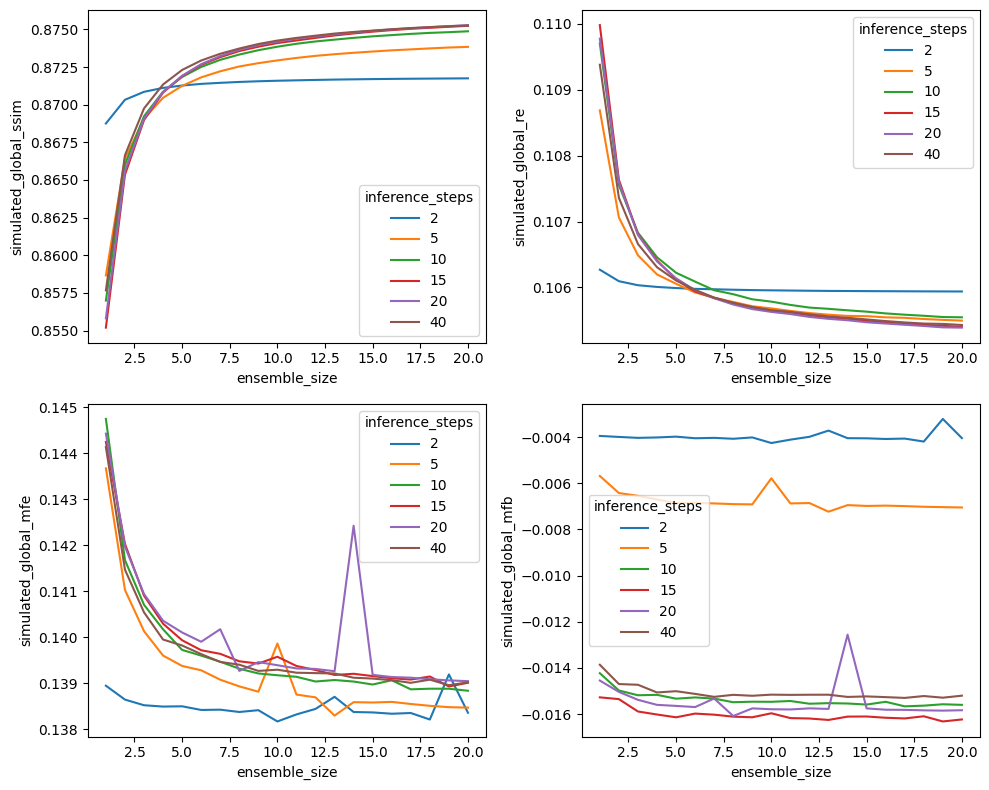

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

palette = sns.color_palette("tab10", 6)

sns.lineplot(data=ensemble_df, x="ensemble_size", y="simulated_global_ssim", hue="inference_steps", markers=True, palette=palette, ax=ax[0][0])
sns.lineplot(data=ensemble_df, x="ensemble_size", y="simulated_global_re", hue="inference_steps", markers=True, palette=palette, ax=ax[0][1])
sns.lineplot(data=ensemble_df, x="ensemble_size", y="simulated_global_mfe", hue="inference_steps", markers=True, palette=palette, ax=ax[1][0])
sns.lineplot(data=ensemble_df, x="ensemble_size", y="simulated_global_mfb", hue="inference_steps", markers=True, palette=palette, ax=ax[1][1])

plt.tight_layout()
plt.show()

In [9]:
results = np.load('paper_results/predictions/diffusion/ensemble/inf_' + str(inf_steps_list[k]) + '_results.npz')

In [10]:
results['simulated_pollutants_ssim'].shape

(20, 4)

0.7186153
0.7239168
0.7267277
0.727491
0.7277058
0.7278439


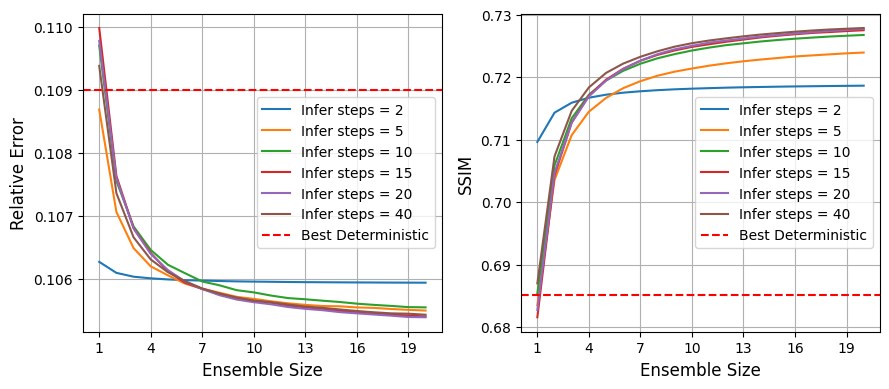

In [13]:
import numpy as np
import matplotlib.pyplot as plt

inf_steps_list = [2,5,10,15,20,40]

f, ax = plt.subplots(1, 2, figsize=(9,4))
c=0
title = ['re', 'ssim', 'mfe', 'mfb']
sub = ['Relative Error', 'SSIM']
for k in range(len(inf_steps_list)):
    c=0
    results = np.load('paper_results/predictions/diffusion/ensemble/inf_' + str(inf_steps_list[k]) + '_results.npz')

    for i in range(2):
        for j in range(1):  
            if title[c] == 'ssim':
                plot_metric = np.mean(results['simulated_pollutants_ssim'], axis=1)
                print(plot_metric.max())
            else:
                plot_metric = results['simulated_global_'+title[c]]

            ax[i].plot(np.linspace(1, 20,20), plot_metric, label='Infer steps = ' + str(inf_steps_list[k]))
            ax[i].grid()
            #ax[i].set_title(sub[c] + ' Ensemble Size vs ' + title[c].upper())
            ax[i].set_xlabel('Ensemble Size', fontsize=12)
            ax[i].set_ylabel(sub[c], fontsize=12)
            ax[i].legend()
            c+=1

ax[0].axhline(0.10899845374848895, linestyle='--', label='Best Deterministic', color='red')
ax[1].axhline(0.6850986480712891, linestyle='--', label='Best Deterministic', color='red')
#ax[1,0].axhline(unet_mean_err[2], linestyle='--', label='Discriminative', color='red')
#ax[1,1].axhline(unet_mean_err[3], linestyle='--', label='Discriminative', color='red')
for i in range(2):
    for j in range(1): 
        ax[i].legend()
        ax[i].grid()
        ax[i].set_xticks([1, 4,7,10,13,16,19])

plt.tight_layout()

plt.savefig('paper_images/ensemble_global.png')

### Noise comparisons

In [9]:
ensemble_df[
                (ensemble_df['inference_steps'] == 15) &
                (ensemble_df['ensemble_size'] == 20)
            ].iloc[0]

inference_steps           15.000000
ensemble_size             20.000000
simulated_global_ssim      0.875234
simulated_global_re        0.105403
simulated_global_rmse      3.482222
simulated_global_rrmse     0.109462
simulated_global_mfe       0.139009
simulated_global_mfb      -0.016236
Name: 79, dtype: float64

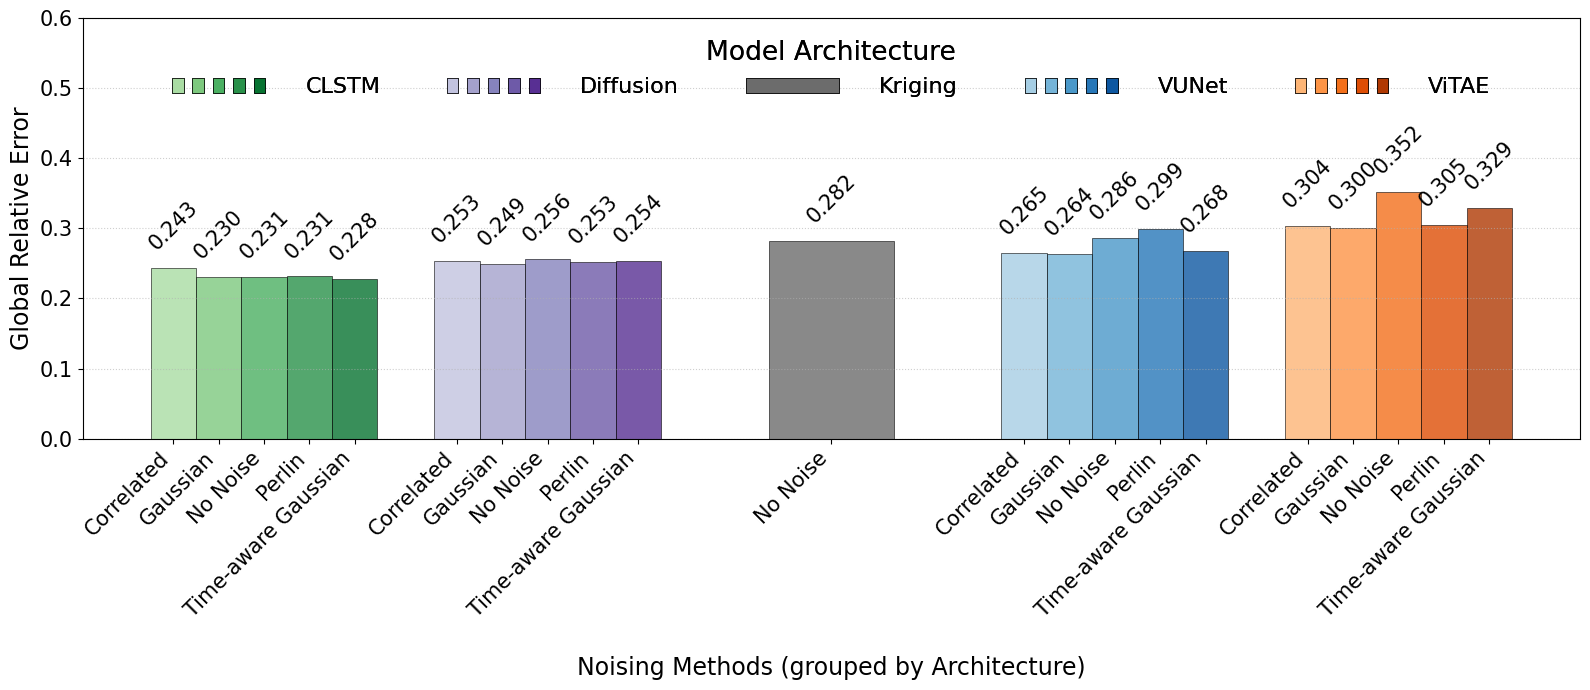

In [10]:
from src.utils.visualization import plot_experiment_barcharts, plot_grouped_paper_real_results
import pandas as pd
import numpy as np

metric = "re"
y_axis_name = "Global Relative Error"

def read_noise_results_df() -> pd.DataFrame:

    # CLSTM

    clstm_results = np.load('paper_results/predictions/clstm/t8_42_fixed_results.npz')
    clstm_results_gaussian = np.load('paper_results/predictions/clstm/gaussian_fixed_results.npz')
    clstm_results_time_gaussian = np.load('paper_results/predictions/clstm/time_gaussian_fixed_results.npz')
    clstm_results_perlin = np.load('paper_results/predictions/clstm/perlin_fixed_results.npz')
    clstm_results_correlated = np.load('paper_results/predictions/clstm/correlated_fixed_results.npz')

    # ViTAE

    vitae_results = np.load('paper_results/predictions/vitae/t6_42_fixed_results.npz')
    vitae_results_gaussian = np.load('paper_results/predictions/vitae/gaussian_fixed_results.npz')
    vitae_results_time_gaussian = np.load('paper_results/predictions/vitae/time_gaussian_fixed_results.npz')
    vitae_results_perlin = np.load('paper_results/predictions/vitae/perlin_fixed_results.npz')
    vitae_results_correlated = np.load('paper_results/predictions/vitae/correlated_fixed_results.npz')

    # VUNet

    vunet_results = np.load('paper_results/predictions/vunet/t3_42_fixed_results.npz')
    vunet_results_gaussian = np.load('paper_results/predictions/vunet/gaussian_fixed_results.npz')
    vunet_results_time_gaussian = np.load('paper_results/predictions/vunet/time_gaussian_fixed_results.npz')
    vunet_results_perlin = np.load('paper_results/predictions/vunet/perlin_fixed_results.npz')
    vunet_results_correlated = np.load('paper_results/predictions/vunet/correlated_fixed_results.npz')

    # Diffusion

    diffusion_results = np.load('paper_results/predictions/diffusion/short_training_fixed_results.npz')
    diffusion_results_gaussian = np.load('paper_results/predictions/diffusion/gaussian_fixed_results.npz')
    diffusion_results_time_gaussian = np.load('paper_results/predictions/diffusion/time_gaussian_fixed_results.npz')
    diffusion_results_perlin = np.load('paper_results/predictions/diffusion/perlin_fixed_results.npz')
    diffusion_results_correlated = np.load('paper_results/predictions/diffusion/correlated_fixed_results.npz')

    # Kriging

    kriging_results_real = np.load('paper_results/predictions/kriging/kriging_paper_fixed_results.npz')

    models_data = {
        "Experiment Name": [
            "CLSTM",
            "CLSTM - Gaussian",
            "CLSTM - Time-aware Gaussian",
            "CLSTM - Perlin",
            "CLSTM - Correlated",

            "ViTAE",
            "ViTAE - Gaussian",
            "ViTAE - Time-aware Gaussian",
            "ViTAE - Perlin",
            "ViTAE - Correlated",

            "VUNet",
            "VUNet - Gaussian",
            "VUNet - Time-aware Gaussian",
            "VUNet - Perlin",
            "VUNet - Correlated",
            
            "Diffusion",
            "Diffusion - Gaussian",
            "Diffusion - Time-aware Gaussian",
            "Diffusion - Perlin",
            "Diffusion - Correlated",

            "Kriging"
        ],
        "Error": [
            np.mean(clstm_results[f'real_global_{metric}']),
            np.mean(clstm_results_gaussian[f'real_global_{metric}']),
            np.mean(clstm_results_time_gaussian[f'real_global_{metric}']),
            np.mean(clstm_results_perlin[f'real_global_{metric}']),
            np.mean(clstm_results_correlated[f'real_global_{metric}']),

            np.mean(vitae_results[f'real_global_{metric}']),
            np.mean(vitae_results_gaussian[f'real_global_{metric}']),
            np.mean(vitae_results_time_gaussian[f'real_global_{metric}']),
            np.mean(vitae_results_perlin[f'real_global_{metric}']),
            np.mean(vitae_results_correlated[f'real_global_{metric}']),

            np.mean(vunet_results[f'real_global_{metric}']),
            np.mean(vunet_results_gaussian[f'real_global_{metric}']),
            np.mean(vunet_results_time_gaussian[f'real_global_{metric}']),
            np.mean(vunet_results_perlin[f'real_global_{metric}']),
            np.mean(vunet_results_correlated[f'real_global_{metric}']),
            
            np.mean(diffusion_results[f'real_global_{metric}']),
            np.mean(diffusion_results_gaussian[f'real_global_{metric}']),
            np.mean(diffusion_results_time_gaussian[f'real_global_{metric}']),
            np.mean(diffusion_results_perlin[f'real_global_{metric}']),
            np.mean(diffusion_results_correlated[f'real_global_{metric}']),

            np.mean(kriging_results_real[f'real_global_{metric}'])
        ],
        "Seed": [
            42,
            42,
            42,
            42,
            42,

            42,
            42,
            42,
            42,
            42,

            42,
            42,
            42,
            42,
            42,
            
            42,
            42,
            42,
            42,
            42,

            42
        ]
    }
    df = pd.DataFrame(models_data)

    def extract_category(model_name):
        if "CLSTM" in model_name:
            return "CLSTM"
        elif "VUNet" in model_name:
            return "VUNet"
        elif "ViTAE" in model_name:
            return "ViTAE"
        elif "Kriging" in model_name:
            return "Kriging"
        elif "Diffusion" in model_name:
            return "Diffusion"
        else:
            return "Other"
    
    def extract_noising_method(model_name):
        if "Gaussian" in model_name and "Time-aware" not in model_name:
            return "Gaussian"
        elif "Time-aware Gaussian" in model_name:
            return "Time-aware Gaussian"
        elif "Perlin" in model_name:
            return "Perlin"
        elif "Correlated" in model_name:
            return "Correlated"
        else:
            return "No Noise"
        
    df['Model'] = df['Experiment Name'].apply(extract_category)
    df["Noising Method"] = df['Experiment Name'].apply(extract_noising_method)

    return df

df = read_noise_results_df()

# plot_experiment_barcharts(
#     df, 
#     figsize=(10, 6), capsize=4, 
#     annot_size=10, ylim=(0, 0.5),
#     y_axis_name=y_axis_name,
#     file_name="test.png"
#     )

plot_grouped_paper_real_results(df)

In [11]:
# from src.utils.evaluation_pipeline import compute_real_metrics, compute_simulated_metrics, save_results

# files = [
#     # CLSTM
#     ("clstm", "real", "paper_results/predictions/clstm/t8_42_fixed_results.npz"),
#     ("clstm", "gaussian", "paper_results/predictions/clstm/gaussian_fixed_results.npz"),
#     ("clstm", "time_gaussian", "paper_results/predictions/clstm/time_gaussian_fixed_results.npz"),
#     ("clstm", "perlin", "paper_results/predictions/clstm/perlin_fixed_results.npz"),
#     ("clstm", "correlated", "paper_results/predictions/clstm/correlated_fixed_results.npz"),

#     # ViTAE
#     ("vitae", "real", "paper_results/predictions/vitae/t6_42_fixed_results.npz"),
#     ("vitae", "gaussian", "paper_results/predictions/vitae/gaussian_fixed_results.npz"),
#     ("vitae", "time_gaussian", "paper_results/predictions/vitae/time_gaussian_fixed_results.npz"),
#     ("vitae", "perlin", "paper_results/predictions/vitae/perlin_fixed_results.npz"),
#     ("vitae", "correlated", "paper_results/predictions/vitae/correlated_fixed_results.npz"),

#     # VUNet
#     ("vunet", "real", "paper_results/predictions/vunet/t3_42_fixed_results.npz"),
#     ("vunet", "gaussian", "paper_results/predictions/vunet/gaussian_fixed_results.npz"),
#     ("vunet", "time_gaussian", "paper_results/predictions/vunet/time_gaussian_fixed_results.npz"),
#     ("vunet", "perlin", "paper_results/predictions/vunet/perlin_fixed_results.npz"),
#     ("vunet", "correlated", "paper_results/predictions/vunet/correlated_fixed_results.npz"),

#     # Diffusion
#     ("diffusion", "real", "paper_results/predictions/diffusion/short_training_fixed_results.npz"),
#     ("diffusion", "gaussian", "paper_results/predictions/diffusion/gaussian_fixed_results.npz"),
#     ("diffusion", "time_gaussian", "paper_results/predictions/diffusion/time_gaussian_fixed_results.npz"),
#     ("diffusion", "perlin", "paper_results/predictions/diffusion/perlin_fixed_results.npz"),
#     ("diffusion", "correlated", "paper_results/predictions/diffusion/correlated_fixed_results.npz"),

#     # Kriging
#     ("kriging", "real", "paper_results/predictions/kriging/kriging_paper_fixed_results.npz"),
# ]

# for model, variant, file_path in files:
#     if not os.path.exists(file_path):
#         print(f"File {file_path} does not exist, skipping...")
#         continue

#     data = np.load(file_path)

#     results_on_simulated = compute_simulated_metrics(
#         observations=torch.from_numpy(data["simulated_observations"]),
#         ground_truths=torch.from_numpy(data["simulated_ground_truths"]),
#         predictions=torch.from_numpy(data["simulated_predictions"]),
#     )

#     results_on_real = compute_real_metrics(
#         observations=torch.from_numpy(data["real_observations"]),
#         ground_truths=torch.from_numpy(data["real_ground_truths"]),
#         predictions=torch.from_numpy(data["real_predictions"]),
#         target_masks=torch.from_numpy(data["real_target_masks"])
#     )

#     save_results(
#         file_path.replace("results.npz", "fixed_results.npz"),
#         results_on_simulated,
#         results_on_real
#     )

#     print(f"Processed and saved results for {model} - {variant}")

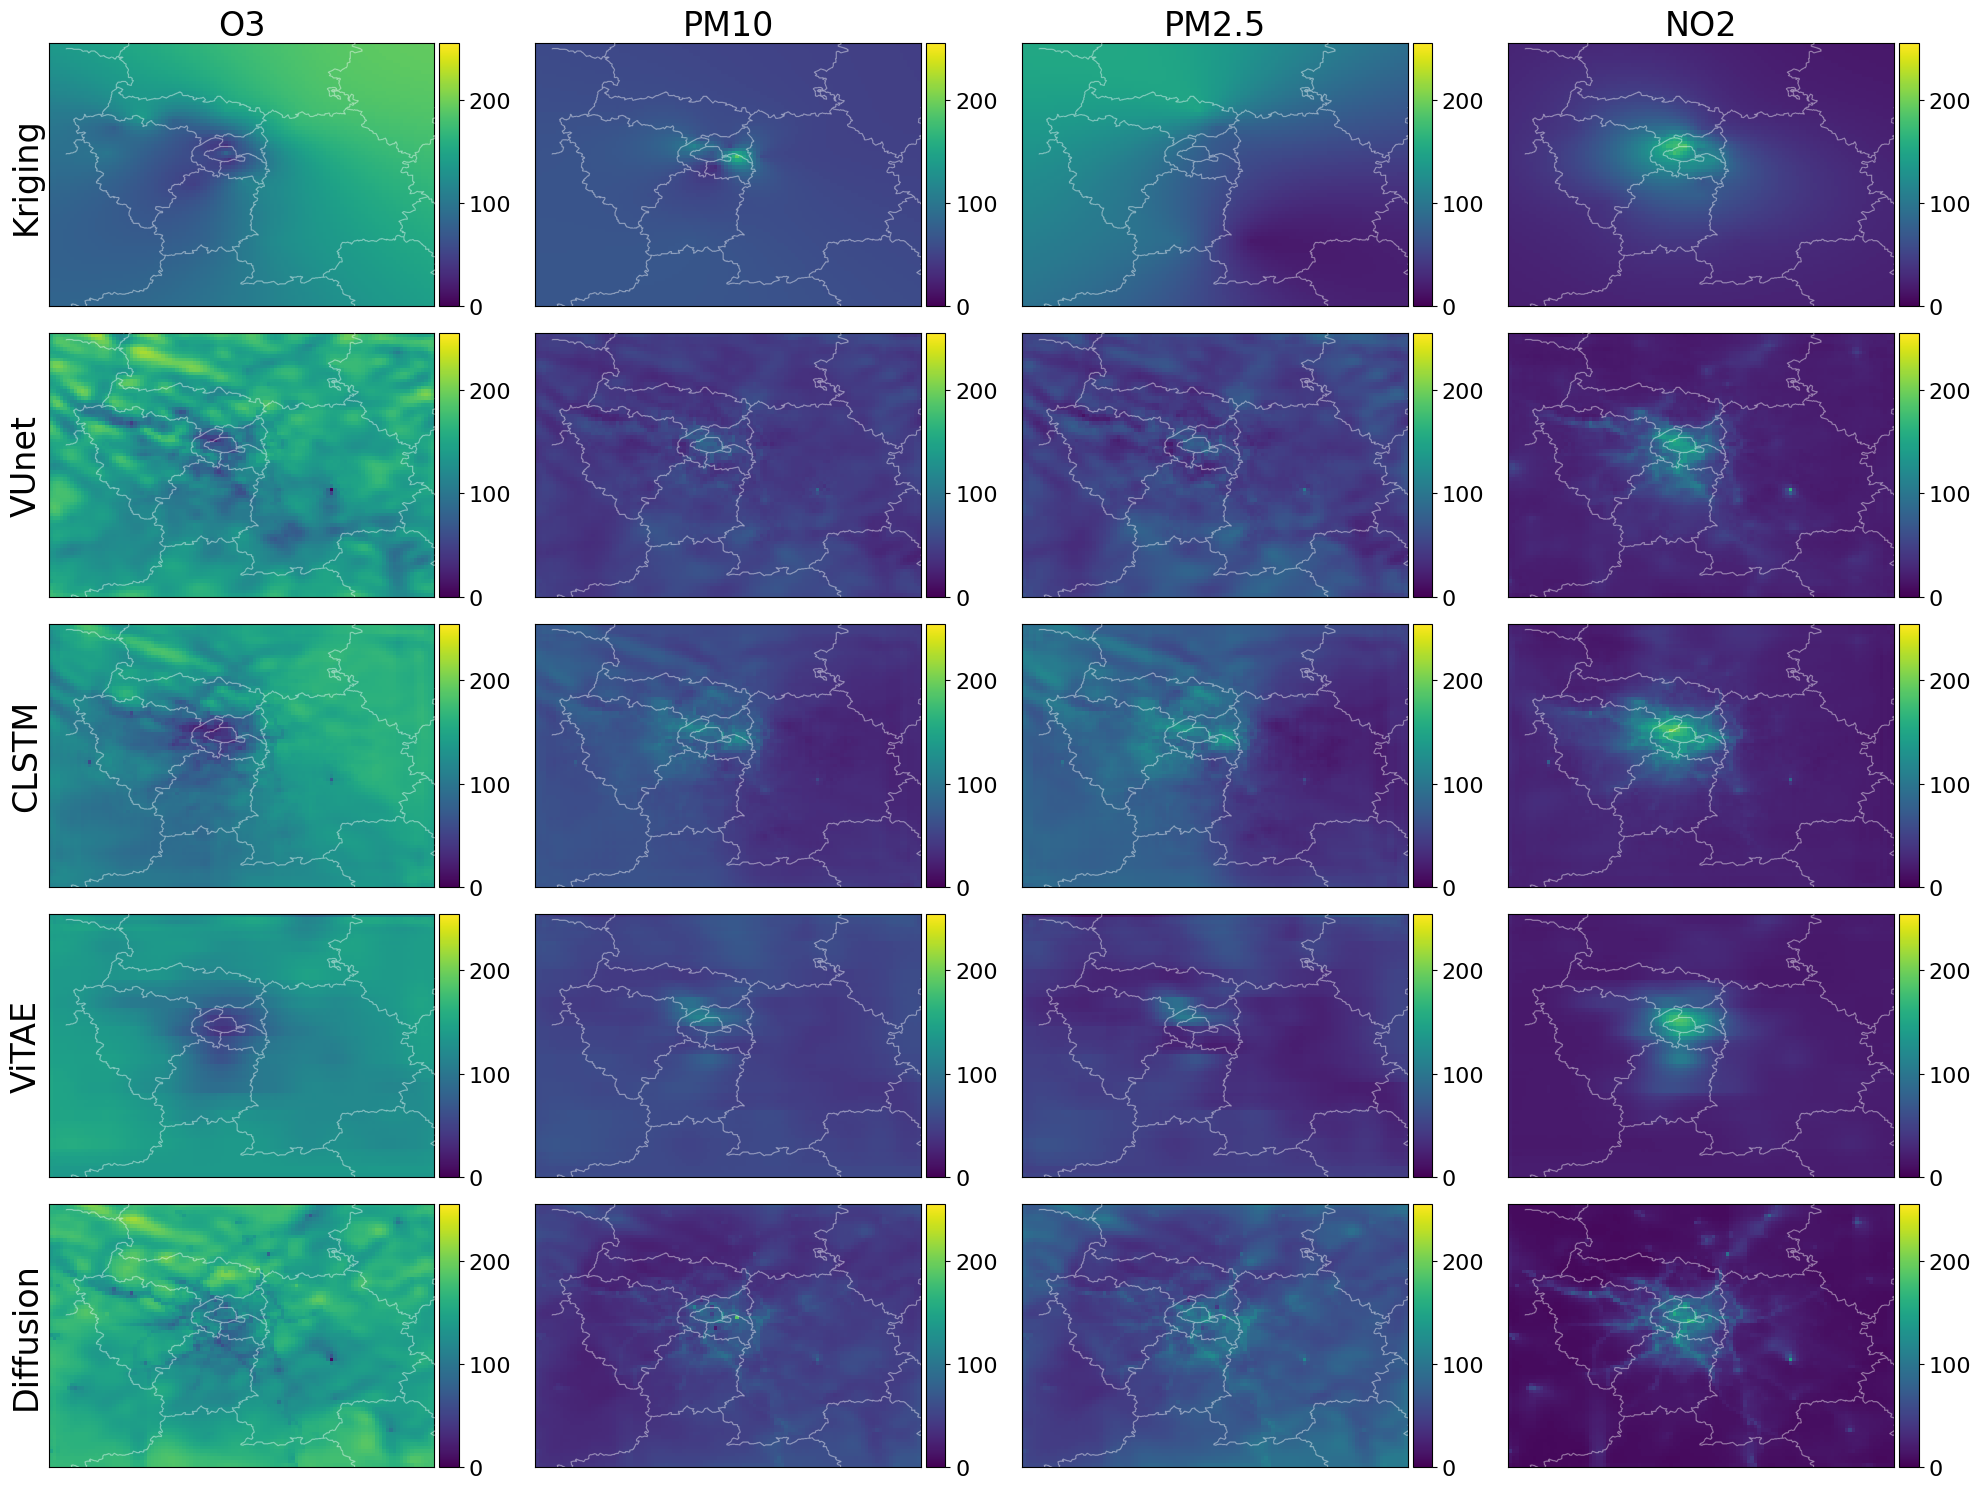

In [4]:
def print_with_borders(img: np.array, ax, vmax: int):
    img_rgb = background_paris.astype(np.uint8)
    mask_lines = (img_rgb < 250).any(axis=2)
    img_rgb[mask_lines] = [255, 255, 255]
    alpha = (mask_lines * 255 * 0.5).astype(np.uint8)
    paris_rgba = np.dstack([img_rgb, alpha])

    ax.imshow(
        np.flipud(img), vmin=0, vmax=vmax, 
        cmap='viridis',
        extent=[0, 110, 0, 75])
    im = ax.imshow(
        paris_rgba,
        origin="upper",          
        extent=[0, 110, 0, 75],
        zorder=10                
    )

    return im

shown_timestep = 300

models_predictions = [
    ("Kriging", np.load('paper_results/predictions/kriging/kriging_paper_fixed_results.npz')['real_predictions']),
    ("VUnet", np.load('paper_results/predictions/vunet/gaussian_fixed_results.npz')['real_predictions']),
    ("CLSTM", np.load('paper_results/predictions/clstm/time_gaussian_fixed_results.npz')['real_predictions']),
    ("ViTAE", np.load('paper_results/predictions/vitae/gaussian_fixed_results.npz')['real_predictions']),
    ("Diffusion", np.load('paper_results/predictions/diffusion/gaussian_fixed_results.npz')['real_predictions']),
]

v_max = [
    np.ceil(np.max([preds[shown_timestep, 0] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 1] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 2] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 3] for _, preds in models_predictions]) / 10 + 1) * 10
]

fig, axs = plt.subplots(len(models_predictions), 4, figsize=(20, 15))
bar_tick_size = 16
label_size = 24

for idx, (model, preds) in enumerate(models_predictions):

    im = print_with_borders(preds[shown_timestep, 0], axs[idx][0], v_max[0])
    divider = make_axes_locatable(axs[idx][0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 1], axs[idx][1], v_max[1])
    divider = make_axes_locatable(axs[idx][1])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 2], axs[idx][2], v_max[2])
    divider = make_axes_locatable(axs[idx][2])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 3], axs[idx][3], v_max[3])
    divider = make_axes_locatable(axs[idx][3])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    if idx == 0:
        axs[idx][0].set_title('O3', fontsize=label_size)
        axs[idx][1].set_title('PM10', fontsize=label_size)
        axs[idx][2].set_title('PM2.5', fontsize=label_size)
        axs[idx][3].set_title('NO2', fontsize=label_size)

    axs[idx][0].set_ylabel(model, fontsize=label_size)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("paper_images/real_predictions.png", dpi=300, bbox_inches="tight")

In [13]:
plot_distribution_comparison("paper_images/data/distributions")

In [9]:
dict_results = {
    "Kriging": np.load('paper_results/predictions/kriging/kriging_paper_fixed_results.npz'),
    
    "VUNet": np.load('paper_results/predictions/vunet/t4_42_results.npz'),
    
    "ViTAE": np.load('paper_results/predictions/vitae/t6_results.npz'),
    
    "CLSTM": np.load('paper_results/predictions/clstm/t8_42_results.npz'),
    
    "Diffusion": np.load('paper_results/predictions/diffusion/short_training_results.npz'),
}
dict_results["Kriging"] = dict(dict_results["Kriging"])


from src.datasets.vitae_dataset import load_data, unscale

_, _, _, stats = load_data()

dict_results["Kriging"]["simulated_predictions"] = unscale(dict_results["Kriging"]["simulated_predictions"], "min-max", **stats)
dict_results["Kriging"]["simulated_ground_truths"] = unscale(dict_results["Kriging"]["simulated_ground_truths"], "min-max", **stats)
dict_results["Kriging"]["real_predictions"] = unscale(dict_results["Kriging"]["real_predictions"], "min-max", **stats)
dict_results["Kriging"]["real_ground_truths"] = unscale(dict_results["Kriging"]["real_ground_truths"], "min-max", **stats)

In [15]:
plot_model_prediction_comparison(
    all_results=dict_results,
    save_dir="paper_images/results/no2_simulated",
    pollutant="no2",
    show_errors=True,
    sample_idx=-100
)

plot_model_prediction_comparison(
    all_results=dict_results,
    save_dir="paper_images/results/o3_simulated",
    pollutant="o3",
    show_errors=True,
    sample_idx=-100
)

plot_model_prediction_comparison(
    all_results=dict_results,
    save_dir="paper_images/results/pm10_simulated",
    pollutant="pm10",
    show_errors=True,
    sample_idx=-100
)

plot_model_prediction_comparison(
    all_results=dict_results,
    save_dir="paper_images/results/pm25_simulated",
    pollutant="pm25",
    show_errors=True,
    sample_idx=-100
)

In [16]:
_ = plot_noise_effects(
    noise_type='gaussian',
    save=False,
    save_dir="paper_images/noised_distributions",
    noise_mean=torch.Tensor([-40, 0, -5, 10]),
    noise_std=torch.Tensor([10, 5, 5, 5]),
    correlation_scale=7.5
)

In [10]:
# ----- Real data -----

# plot_gt_vs_pred(
#     all_results=dict_results,
#     save_dir="paper_images/gt_vs_pred_small/no2_simulated",
#     pollutant="no2",
# )

# plot_gt_vs_pred(
#     all_results=dict_results,
#     save_dir="paper_images/gt_vs_pred_small/o3_simulated",
#     pollutant="o3",
# )

# plot_gt_vs_pred(
#     all_results=dict_results,
#     save_dir="paper_images/gt_vs_pred_small/pm10_simulated",
#     pollutant="pm10",
# )

# plot_gt_vs_pred(
#     all_results=dict_results,
#     save_dir="paper_images/gt_vs_pred_small/pm25_simulated",
#     pollutant="pm25",
# )

# ----- Synthetic data -----

plot_gt_vs_pred_simulation(
    all_results=dict_results,
    save_dir="paper_images/gt_vs_pred_small_synth/no2_simulated",
    pollutant="no2",
    gt_column="simulated_ground_truths",
    pred_column="simulated_predictions"
)

plot_gt_vs_pred_simulation(
    all_results=dict_results,
    save_dir="paper_images/gt_vs_pred_small_synth/o3_simulated",
    pollutant="o3",
    gt_column="simulated_ground_truths",
    pred_column="simulated_predictions"
)

plot_gt_vs_pred_simulation(
    all_results=dict_results,
    save_dir="paper_images/gt_vs_pred_small_synth/pm10_simulated",
    pollutant="pm10",
    gt_column="simulated_ground_truths",
    pred_column="simulated_predictions"
)

plot_gt_vs_pred_simulation(
    all_results=dict_results,
    save_dir="paper_images/gt_vs_pred_small_synth/pm25_simulated",
    pollutant="pm25",
    gt_column="simulated_ground_truths",
    pred_column="simulated_predictions"
)

In [21]:
def radial_profile(data):
    y, x = np.indices(data.shape)
    center = np.array(data.shape) // 2
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(int)

    # Radial mean
    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / np.maximum(nr, 1)

    return radialprofile

def calculate_psd(data):
    # FFT and PSD
    F = np.fft.fft2(data)
    F_shift = np.fft.fftshift(F)
    psd2D = np.abs(F_shift) ** 2

    # Radially averaged PSD
    psd1D = radial_profile(psd2D)

    # normalize
    total = np.sum(psd1D)

    return psd1D

def cal_average(data, idx):
    # data is of shape: [N,d,75,110]
    N = data.shape[idx]
    sum_psd = None
    sumsq_psd = None

    for i in range(N):
        img = data[i][idx]
        psd = calculate_psd(img)

        # Initialize
        if sum_psd is None:
            sum_psd = np.zeros(len(psd), dtype=np.float64)
            sumsq_psd = np.zeros(len(psd), dtype=np.float64)

        sum_psd += psd
        sumsq_psd += psd**2

    mean_psd = sum_psd / N
    var_psd = (sumsq_psd / N) - (mean_psd ** 2)
    std_psd = np.sqrt(var_psd)
    freq = np.arange(len(psd))

    return freq, mean_psd, std_psd
        

def plot_avgPSD(ground_truth, idx, pred=None, model_name=None):
    '''
    idx = 0 for NO2
    idx = 1 for O3
    idx = 2 for PM10
    idx = 3 for PM2.5
    '''
    title = {0:'NO2', 1:'O3', 2:'PM10', 3:'PM2.5'}

    freq, mean_gt, std_gt = cal_average(ground_truth, idx)
    #eps = 1e-12
    #lower = mean_gt - std_gt
    #upper = mean_gt + std_gt

    plt.figure(figsize=(5,4))

    plt.plot(np.log(mean_gt), label='Ground truth')
    #plt.fill_between(freq[1:], np.log(lower[1:]), np.log(upper[1:]), alpha=0.3)

    if pred is not None:
        _, psd_diff, _ = cal_average(pred, idx)
        plt.plot(np.log(psd_diff), label=model_name)

    plt.title('Radical Averaged Power Spectral Density ' + title[idx])
    plt.ylabel('Mean of log(Power)')
    plt.xlabel('Spatial Frequency Radius')

    plt.grid()
    plt.tight_layout()
    plt.legend()

    save_dir = f"paper_images/psd/{model_name}/"
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}PSD_metric_{title[idx]}.png')

def plot_all(dict_res):
    title = {0:'NO2', 1:'O3', 2:'PM10', 3:'PM2.5'}
    ground_truth = dict_res["Diffusion"]["simulated_ground_truths"]

    for idx in range(4):
        _, mean_gt, _ = cal_average(ground_truth, idx)
        np.save(f"tmp/gt_{title[idx]}", mean_gt)

        plt.figure(figsize=(5,4))
        plt.plot(np.log(mean_gt), label='Ground truth')

        for model_name in ["Diffusion", "VUNet", "ViTAE", "CLSTM", "Kriging"]:
            pred = dict_results[model_name]["simulated_predictions"]
            _, psd_diff, _ = cal_average(pred, idx)

            np.save(f"tmp/{model_name}_{title[idx]}", psd_diff)

            plt.plot(np.log(psd_diff), label=model_name)

        plt.title('Radical Averaged Power Spectral Density ' + title[idx])
        plt.ylabel('Mean of log(Power)')
        plt.xlabel('Spatial Frequency Radius')

        plt.grid()
        plt.tight_layout()
        plt.legend()

        save_dir = f"paper_images/psd/"
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f'{save_dir}PSD_metric_{title[idx]}.png')



def iterate_psd(gt, pred, model_name):
    for idx in range(4):
        plot_avgPSD(gt, idx, pred, model_name)

for model_name in ["Diffusion", "VUNet", "ViTAE", "CLSTM", "Kriging"]:
    iterate_psd(dict_results[model_name]["simulated_ground_truths"], dict_results[model_name]["simulated_predictions"], model_name)

plot_all(dict_results)

### Joint vs Individual bar plot

In [2]:
dict_results_joint = {
    "VUNet": np.load('paper_results/predictions/vunet/t4_42_results.npz'),
    
    "ViTAE": np.load('paper_results/predictions/vitae/t6_results.npz'),
    
    "CLSTM": np.load('paper_results/predictions/clstm/t8_42_results.npz'),
    
    "Diffusion": np.load('paper_results/predictions/diffusion/short_training_results.npz'),
}

In [13]:
dict_results_indi = {
    "VUNet": np.load('paper_results/predictions/vunet/no2/no_noise_results.npz'),
    
    "ViTAE":np.load('paper_results/predictions/vitae/no2/no_noise_results.npz'),
    
    "CLSTM": np.load('paper_results/predictions/clstm/no2/no_noise_results.npz'),
    
    "Diffusion": np.load('paper_results/predictions/diffusion/no2/real-random_results.npz')
}

In [14]:
sample_idx = 20

v_max_joint = np.max([max(np.max(res['simulated_ground_truths'][sample_idx, 3]), np.max(res['simulated_predictions'][sample_idx, 3])) for res in dict_results_joint.values()])

if True:
    try:
        v_max_errors_joint = max([np.max(np.abs(res['real_local_errors'][sample_idx, 3])) for res in dict_results_joint.values()])
    except:
        v_max_errors_joint = max([
            np.max(np.abs(compute_local_error(torch.from_numpy(res['simulated_ground_truths'][sample_idx, 3]), torch.from_numpy(res['simulated_predictions'][sample_idx, 3])).numpy())) 
            for res in dict_results_joint.values()
            ])



v_max_indi = np.max([max(np.max(res['simulated_ground_truths'][sample_idx, 0]), np.max(res['simulated_predictions'][sample_idx, 0])) for res in dict_results_indi.values()])

if True:
    try:
        v_max_errors_indi = max([np.max(np.abs(res['real_local_errors'][sample_idx, 0])) for res in dict_results_indi.values()])
    except:
        v_max_errors_indi = max([
            np.max(np.abs(compute_local_error(torch.from_numpy(res['simulated_ground_truths'][sample_idx, 0]), torch.from_numpy(res['simulated_predictions'][sample_idx, 0])).numpy())) 
            for res in dict_results_indi.values()
            ])

In [10]:
max(v_max_joint, v_max_indi)

np.float32(25.011847)

In [15]:


plot_model_prediction_comparison(
    all_results=dict_results_joint,
    save_dir="paper_images/results/no2_simulated",
    pollutant="no2",
    show_errors=True,
    sample_idx=sample_idx,
    individual_model=False,
    v_max = max(v_max_joint, v_max_indi),
    v_max_errors = max(v_max_errors_indi, v_max_errors_joint)
)

plot_model_prediction_comparison(
    all_results=dict_results_indi,
    save_dir="paper_images/results/no2_simulated_individual",
    pollutant="no2",
    show_errors=True,
    sample_idx=sample_idx,
    individual_model=True,
    v_max = max(v_max_joint, v_max_indi),
    v_max_errors = max(v_max_errors_indi, v_max_errors_joint)
)

In [2]:
import numpy as np

joint_unet = np.load('paper_results/predictions/vunet/t4_42_results.npz')
joint_vitae = np.load('paper_results/predictions/vitae/t6_results.npz')
joint_clstm = np.load('paper_results/predictions/clstm/t8_42_results.npz')
joint_diffusion = np.load('paper_results/predictions/diffusion/short_training_results.npz')

indi_unet = [
    np.load('paper_results/predictions/vunet/o3/no_noise_results.npz'), #o3
    np.load('paper_results/predictions/vunet/pm10/no_noise_results.npz'), #pm10
    np.load('paper_results/predictions/vunet/pm25/no_noise_results.npz'), #pm2.5
    np.load('paper_results/predictions/vunet/no2/no_noise_results.npz')
]

indi_vitae = [
    np.load('paper_results/predictions/vitae/o3/no_noise_results.npz'), #o3
    np.load('paper_results/predictions/vitae/pm10/no_noise_results.npz'), #pm10
    np.load('paper_results/predictions/vitae/pm25/no_noise_results.npz'), #pm2.5
    np.load('paper_results/predictions/vitae/no2/no_noise_results.npz')
]

indi_diffusion = [
    np.load('paper_results/predictions/diffusion/o3/real-random_results.npz'), #o3
    np.load('paper_results/predictions/diffusion/pm10/real-random_results.npz'), #pm10
    np.load('paper_results/predictions/diffusion/pm25/real-random_results.npz'), #pm2.5
    np.load('paper_results/predictions/diffusion/no2/real-random_results.npz') #no2
]

indi_clstm = [
    np.load('paper_results/predictions/clstm/o3/no_noise_results.npz'), #o3
    np.load('paper_results/predictions/clstm/pm10/no_noise_results.npz'), #pm10
    np.load('paper_results/predictions/clstm/pm25/no_noise_results.npz'), #pm2.5
    np.load('paper_results/predictions/clstm/no2/no_noise_results.npz')
]



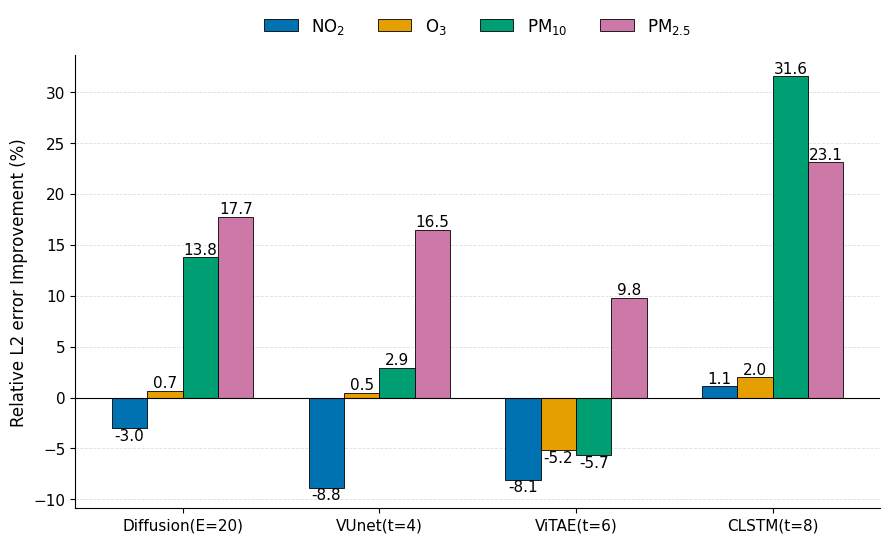

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MRE values
# ============================================================

models = ["Diffusion(E=20)", "VUnet(t=4)", "ViTAE(t=6)", "CLSTM(t=8)"]
pollutants = [r"NO$_2$", r"O$_3$", r"PM$_{10}$", r"PM$_{2.5}$"]

# Enter your MRE values here
mre_indi = {
    "Diffusion(E=20)": [indi_diffusion[3]['simulated_global_re'], indi_diffusion[0]['simulated_global_re'], indi_diffusion[1]['simulated_global_re'], indi_diffusion[2]['simulated_global_re']],
    "VUnet(t=4)":     [indi_unet[3]['simulated_global_re'], indi_unet[0]['simulated_global_re'], indi_unet[1]['simulated_global_re'], indi_unet[2]['simulated_global_re']],
    "ViTAE(t=6)": [indi_vitae[3]['simulated_global_re'], indi_vitae[0]['simulated_global_re'], indi_vitae[1]['simulated_global_re'], indi_vitae[2]['simulated_global_re']],
    "CLSTM(t=8)":     [indi_clstm[3]['simulated_global_re'], indi_clstm[0]['simulated_global_re'], indi_clstm[1]['simulated_global_re'], indi_clstm[2]['simulated_global_re']]
}

mre_joint = {
    "Diffusion(E=20)": [joint_diffusion['simulated_pollutants_re'][3], joint_diffusion['simulated_pollutants_re'][0], joint_diffusion['simulated_pollutants_re'][1], joint_diffusion['simulated_pollutants_re'][2]],
    "VUnet(t=4)":     [joint_unet['simulated_pollutants_re'][3], joint_unet['simulated_pollutants_re'][0], joint_unet['simulated_pollutants_re'][1], joint_unet['simulated_pollutants_re'][2]],
    "ViTAE(t=6)": [joint_vitae['simulated_pollutants_re'][3], joint_vitae['simulated_pollutants_re'][0], joint_vitae['simulated_pollutants_re'][1], joint_vitae['simulated_pollutants_re'][2]],
    "CLSTM(t=8)":     [joint_clstm['simulated_pollutants_re'][3], joint_clstm['simulated_pollutants_re'][0], joint_clstm['simulated_pollutants_re'][1], joint_clstm['simulated_pollutants_re'][2]]
}


# ============================================================
# Calculate MRE improvement (%)
# Lower MRE = better
# ============================================================

improvement = {}

for model in models:
    v1 = np.array(mre_indi[model], dtype=float)
    v2 = np.array(mre_joint[model], dtype=float)

    improvement[model] = (v1 - v2) / v1 * 100


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5.5))

# Colorblind-friendly academic palette
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # purple
]

n_models = len(models)
n_pollutants = len(pollutants)

bar_width = 0.18
group_spacing = 1.0

x = np.arange(n_models) * group_spacing

for i, pollutant in enumerate(pollutants):

    values = [
        improvement[model][i]
        for model in models
    ]

    positions = x + (i - (n_pollutants - 1) / 2) * bar_width

    bars = ax.bar(
        positions,
        values,
        width=bar_width,
        label=pollutant,
        color=colors[i],
        edgecolor="black",
        linewidth=0.6,
    )

    # Value labels
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=11,
        )


# ============================================================
# Formatting
# ============================================================

ax.set_ylabel("Relative L2 error Improvement (%)", fontsize=12)
#ax.set_xlabel("Model", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

ax.tick_params(axis="y", labelsize=11)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

ax.set_axisbelow(True)

# Legend
ax.legend(
    ncol=4,
    frameon=False,
    fontsize=12,
    title_fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
)

# Remove unnecessary top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save high-resolution versions

plt.savefig(
    "paper_images/MRE_improvement.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [57]:
m = torch.from_numpy(np.load('data/real/real_random_obs_mask.npy'))
t = torch.from_numpy(np.load('data/real/real_random_target_mask.npy'))

## Uncertainity Quantification for Diffusion

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def evaluate_by_pollutant(
    ground_truth,
    prediction,
    target_mask,
    dir_save,
    pollutant_names=None,
    figsize=None,
    max_scatter_points=15000,
    n_crps_bins=30
):
    """
    Uncertainty quantification evaluation for all pollutants.

    No inner/outer-city separation is used.

    Parameters
    ----------
    ground_truth : np.ndarray
        Shape: (N, P, H, W)

    prediction : np.ndarray
        Shape: (N, M, P, H, W)

    target_mask : np.ndarray
        Shape: (N, P, H, W)
        1 = observed sensor location
        0 = unobserved location

    pollutant_names : list[str], optional
        Names of pollutants.

    figsize : tuple, optional
        Figure size.

    max_scatter_points : int
        Maximum number of points shown in scatter plots.

    n_crps_bins : int
        Number of bins for CRPS histograms.

    Returns
    -------
    all_results : dict
        Metrics for each pollutant.
    """

    # =========================================================
    # Convert inputs
    # =========================================================

    ground_truth = np.asarray(ground_truth)
    prediction = np.asarray(prediction)
    target_mask = np.asarray(target_mask).astype(bool)

    N, P, H, W = ground_truth.shape
    M = prediction.shape[1]

    assert prediction.shape == (N, M, P, H, W)
    assert target_mask.shape == (N, P, H, W)

    if pollutant_names is None:
        pollutant_names = [
            f"Pollutant {i+1}"
            for i in range(P)
        ]

    assert len(pollutant_names) == P

    MAIN_COLOR = "#2166AC"
    GRID_COLOR = "#D9D9D9"
    TEXT_COLOR = "#262626"

    if figsize is None:
        figsize = (15, 3.6 * P)

    fig, axes = plt.subplots(P,3,figsize=figsize,squeeze=False)
    all_results = {}

    # Loop over pollutants

    for p in range(P):
        pollutant = pollutant_names[p]

        gt = ground_truth[:, p, :, :]
        pred = prediction[:, :, p, :, :]
        mask = target_mask[:, p, :, :]

        gt_values = gt[mask]

        pred_values = pred.transpose(0, 2, 3, 1)[mask]
        pred_values = pred_values.T

        # pred_values shape:(20, number_of_sensor_locations)
        # gt_values shape:(number_of_sensor_locations)

        # 1. ENSEMBLE SPREAD

        ensemble_mean = np.mean(pred_values,axis=0)

        ensemble_spread = np.std(pred_values,axis=0,ddof=1)

        absolute_error = np.abs(ensemble_mean - gt_values)

        # 2. SPEARMAN CORRELATION

        rho, p_value = spearmanr(ensemble_spread,absolute_error)

        # 3. CRPS
        term1 = np.mean(np.abs(pred_values -gt_values[None, :]),axis=0)

        # Pairwise ensemble differences
        pairwise_difference = np.abs(pred_values[:, None, :] -pred_values[None, :, :])

        term2 = 0.5 * np.mean(pairwise_difference,axis=(0, 1))

        crps = term1 - term2
        print("Term 1", np.mean(term1))
        print("Term 2", np.mean(term2))
        mean_crps = np.mean(crps)

        # 4. RANK HISTOGRAM
        ranks = np.sum(pred_values < gt_values[None, :],axis=0)

        rank_counts = np.bincount(ranks,minlength=M + 1)

        rank_frequency = (rank_counts /np.sum(rank_counts))

        # STORE RESULTS

        all_results[pollutant] = {
            "n_observations": len(gt_values),
            "ensemble_spread": ensemble_spread,
            "absolute_error": absolute_error,
            "spearman_rho": rho,
            "spearman_pvalue": p_value,
            "crps": crps,
            "mean_crps": mean_crps,
            "rank_counts": rank_counts,
            "rank_frequency": rank_frequency
        }


        ax_scatter = axes[p, 0]
        ax_crps = axes[p, 1]
        ax_rank = axes[p, 2]
        # SCATTER PLOT

        # Subsample only for visualization.

        rng = np.random.default_rng(42 + p)
        n_points = len(ensemble_spread)

        if n_points > max_scatter_points:
            idx = rng.choice(n_points,max_scatter_points,replace=False)

            spread_plot = ensemble_spread[idx]
            error_plot = absolute_error[idx]

        else:
            spread_plot = ensemble_spread
            error_plot = absolute_error

        ax_scatter.scatter(spread_plot,error_plot,s=8,alpha=0.22,color=MAIN_COLOR,edgecolors="none",rasterized=True)

        # Correlation annotation

        ax_scatter.text(
            0.97,
            0.95,
            f"Spearman ρ = {rho:.2f}",
            transform=ax_scatter.transAxes,
            ha="right",
            va="top",
            fontsize=12,
            color=TEXT_COLOR,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#BDBDBD",
                alpha=0.9
            )
        )

        ax_scatter.set_xlabel("Ensemble spread",fontsize=12)

        ax_scatter.set_ylabel("Absolute error",fontsize=12)

        ax_scatter.grid(True,linestyle="--",linewidth=0.5,color=GRID_COLOR,alpha=0.7)

        ax_scatter.set_axisbelow(True)

        # CRPS DISTRIBUTION

        bins = np.histogram_bin_edges(
            crps,
            bins=n_crps_bins
        )

        ax_crps.hist(crps,bins=bins,density=True,color=MAIN_COLOR,alpha=0.75,edgecolor="white",linewidth=0.4)

        # Mean CRPS

        ax_crps.axvline(mean_crps,color="black",linestyle="--",linewidth=1.4)

        ax_crps.text(
            0.97,
            0.95,
            f"Mean CRPS = {mean_crps:.3f}",
            transform=ax_crps.transAxes,
            ha="right",
            va="top",
            fontsize=12,
            color=TEXT_COLOR,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#BDBDBD",
                alpha=0.9
            )
        )

        ax_crps.set_xlabel("CRPS",fontsize=12)

        ax_crps.set_ylabel("Density",fontsize=12)

        ax_crps.grid(True,axis="y",linestyle="--",linewidth=0.5,color=GRID_COLOR,alpha=0.7)

        ax_crps.set_axisbelow(True)

        # RANK HISTOGRAM

        rank_positions = np.arange(M + 1)
        ax_rank.bar(rank_positions,rank_counts,width=0.75,color=MAIN_COLOR,alpha=0.8,edgecolor="white",linewidth=0.4)

        # Ideal rank frequency

        ideal_frequency = len(gt_values) / (M + 1)

        ax_rank.axhline(ideal_frequency,color="black",linestyle="--",linewidth=1.2,label="Ideal")

        ax_rank.set_xlabel( "Observation rank",fontsize=12)
        ax_rank.set_ylabel("Number of locations",fontsize=12)

        # Show approximately 6 x-axis labels
        tick_step = max(1,(M + 1) // 5)

        ax_rank.set_xticks(np.arange(0,M + 1,tick_step))

        ax_rank.grid(True,axis="y",linestyle="--",linewidth=0.5,color=GRID_COLOR,alpha=0.7)

        ax_rank.set_axisbelow(True)

        # Pollutant label

        ax_scatter.text(-0.18,0.5,pollutant,transform=ax_scatter.transAxes,rotation=90,
            va="center",ha="center",fontsize=12,color=TEXT_COLOR)

        # Clean spines

        for ax in [ax_scatter,ax_crps,ax_rank]:

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.tick_params(labelsize=9)

    # Column titles
    axes[0, 0].set_title("Ensemble Spread vs. Absolute Error",fontsize=12,pad=10)

    axes[0, 1].set_title("CRPS Distribution",fontsize=12,pad=10)

    axes[0, 2].set_title("Rank Histogram",fontsize=12,pad=10)

    # Overall title

    #fig.suptitle(
    #    "Uncertainty Quantification of Diffusion Model Predictions",
    #    fontsize=14,
    #    fontweight="bold",
    #    y=1.02
    #)

    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.94,
        bottom=0.07,
        wspace=0.28,
        hspace=0.32
    )

    plt.savefig(dir_save, bbox_inches='tight')

    plt.show()

    return all_results

Term 1 13.278292
Term 2 5.1244044
Term 1 7.9124036
Term 2 3.2047002
Term 1 6.539373
Term 2 2.6345096
Term 1 14.540419
Term 2 5.825152


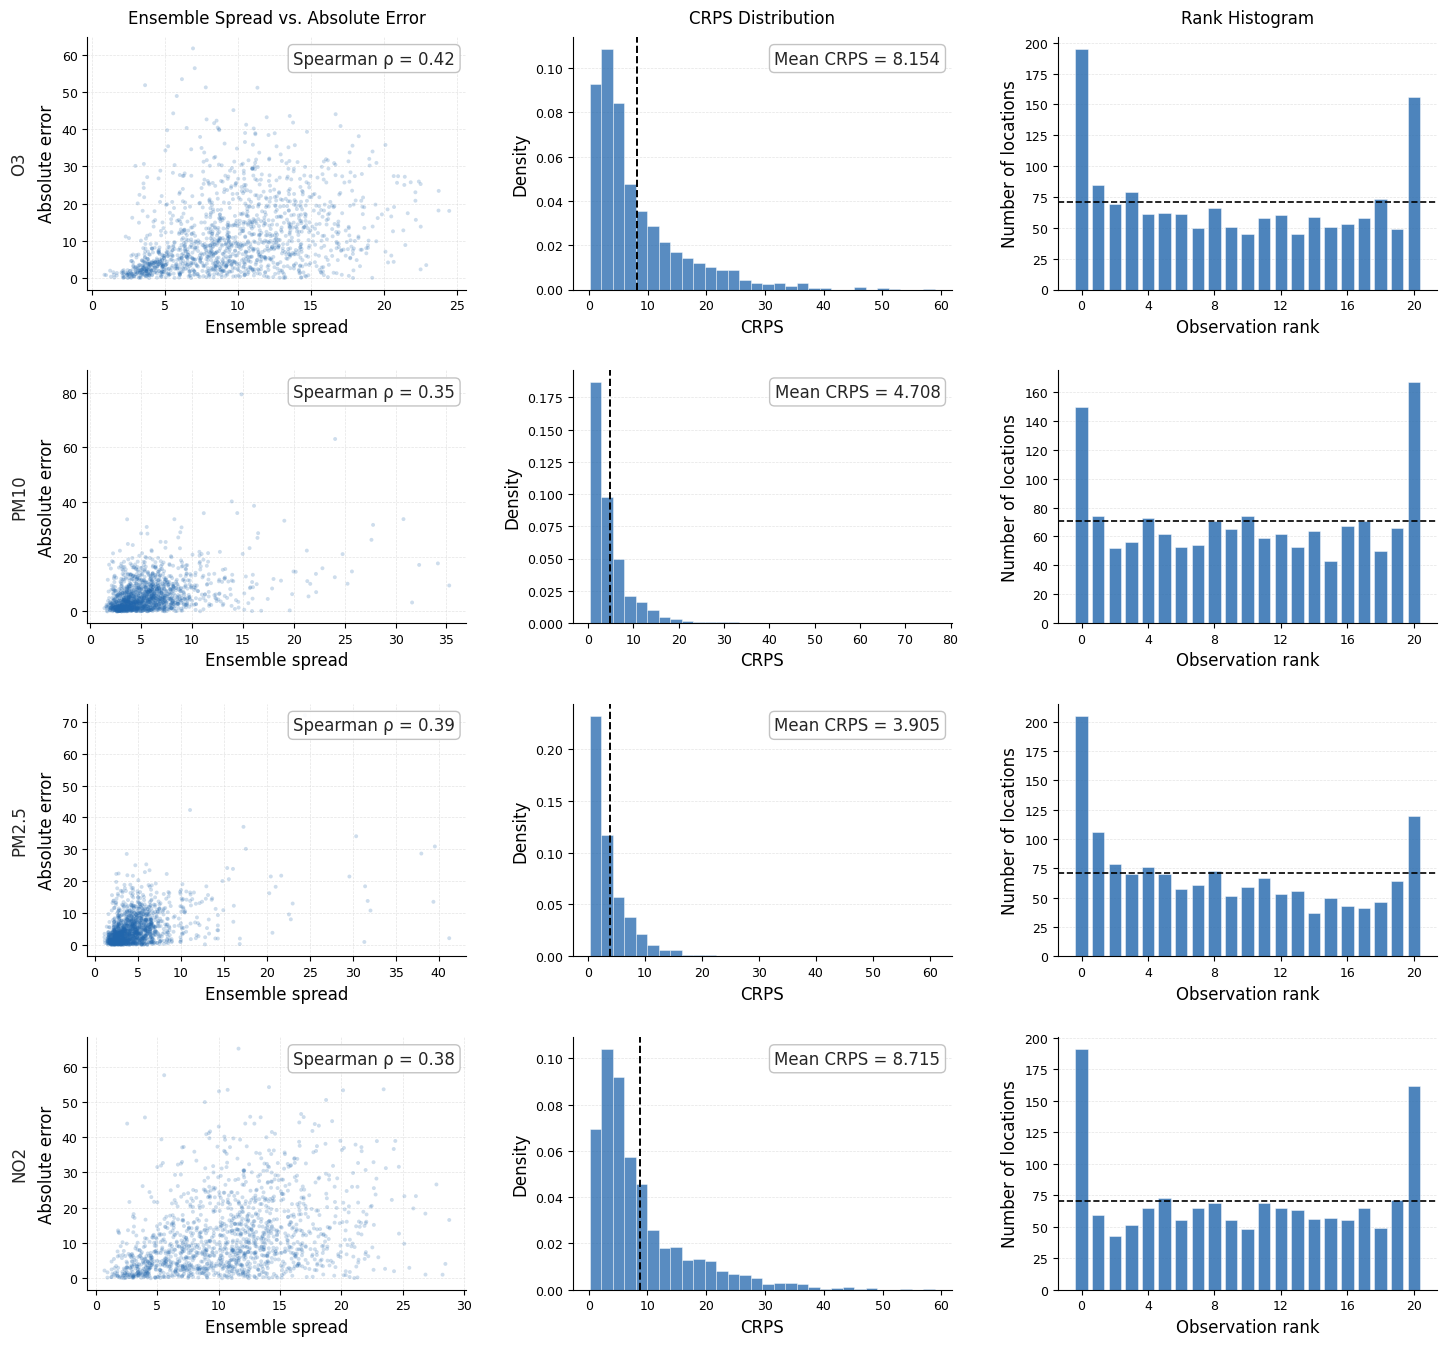

In [53]:
ensemble_pred = np.load('paper_results/predictions/diffusion/ensemble_preds.npz')

obs = ensemble_pred['real_global_observations']  # Voronoi tesselations
ground_truth = ensemble_pred['real_global_ground_truths']
target_mask = ensemble_pred['real_global_target_masks']
pred = ensemble_pred['real_global_predictions']

pred = pred.reshape(743, 20, 4, 75, 110)

results = evaluate_by_pollutant(
    ground_truth,
    pred,
    target_mask,
    dir_save="paper_images/uq_diffusion.png",
    pollutant_names=[
        "O3",
        "PM10",
        "PM2.5",
        "NO2"
    ]
)

Term 1 8.377065796282407
Term 2 0.76515870727713
Term 1 5.638210978509478
Term 2 0.8007492151923701
Term 1 3.86309808400105
Term 2 0.9042691049472449
Term 1 7.179100374389666
Term 2 0.6241107154598989


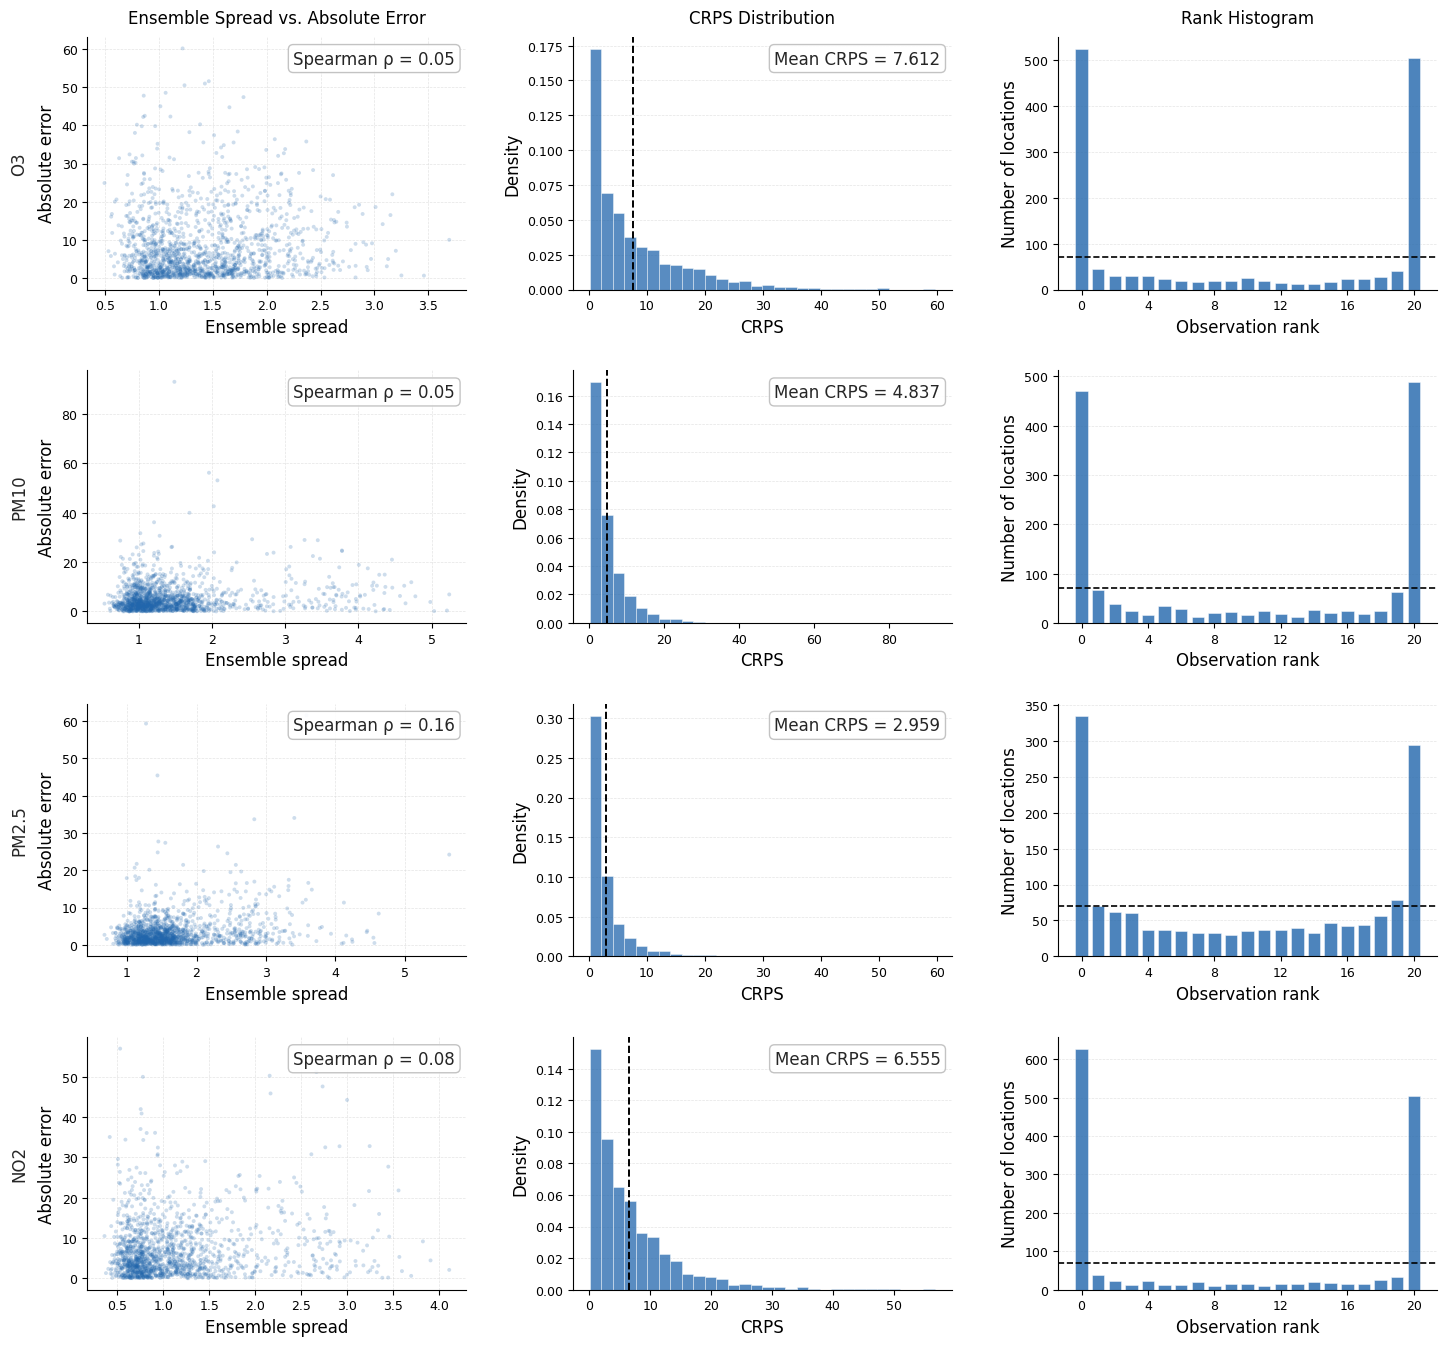

In [52]:
pred_kriging = np.load('paper_results/predictions/kriging/ensemble_results.npz')

ground_truth = pred_kriging['ground_truth_real']
pred = pred_kriging['prediction_real']
target_mask = pred_kriging['target_mask']

results = evaluate_by_pollutant(
    ground_truth,
    pred,
    target_mask,
    dir_save="paper_images/uq_kriging.png",
    pollutant_names=[
        "O3",
        "PM10",
        "PM2.5",
        "NO2"
    ]
)

In [4]:
vunet_ensemble = [
    np.load('paper_results/predictions/vunet/all/t4_21_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_100_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_300_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_400_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_500_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_600_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_700_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_800_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_1000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_3000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_4000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_5000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_6000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_7000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_8000_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_6001_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_7001_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_8001_results.npz'),
    np.load('paper_results/predictions/vunet/t4_42_results.npz'),
    np.load('paper_results/predictions/vunet/t4_results.npz')
]

In [10]:
pred = np.stack(
    [vunet_ensemble[i]['real_predictions'] for i in range(20)],
    axis=1
)

ground_truth = vunet_ensemble[0]['real_ground_truths']
target_mask = vunet_ensemble[0]['real_target_masks']

Term 1 17.494439608678455
Term 2 8.406569321370952
Term 1 10.465387386953187
Term 2 4.1764477520407715
Term 1 7.34089946581517
Term 2 3.7087135510169853
Term 1 21.086167944462407
Term 2 8.681901674469936


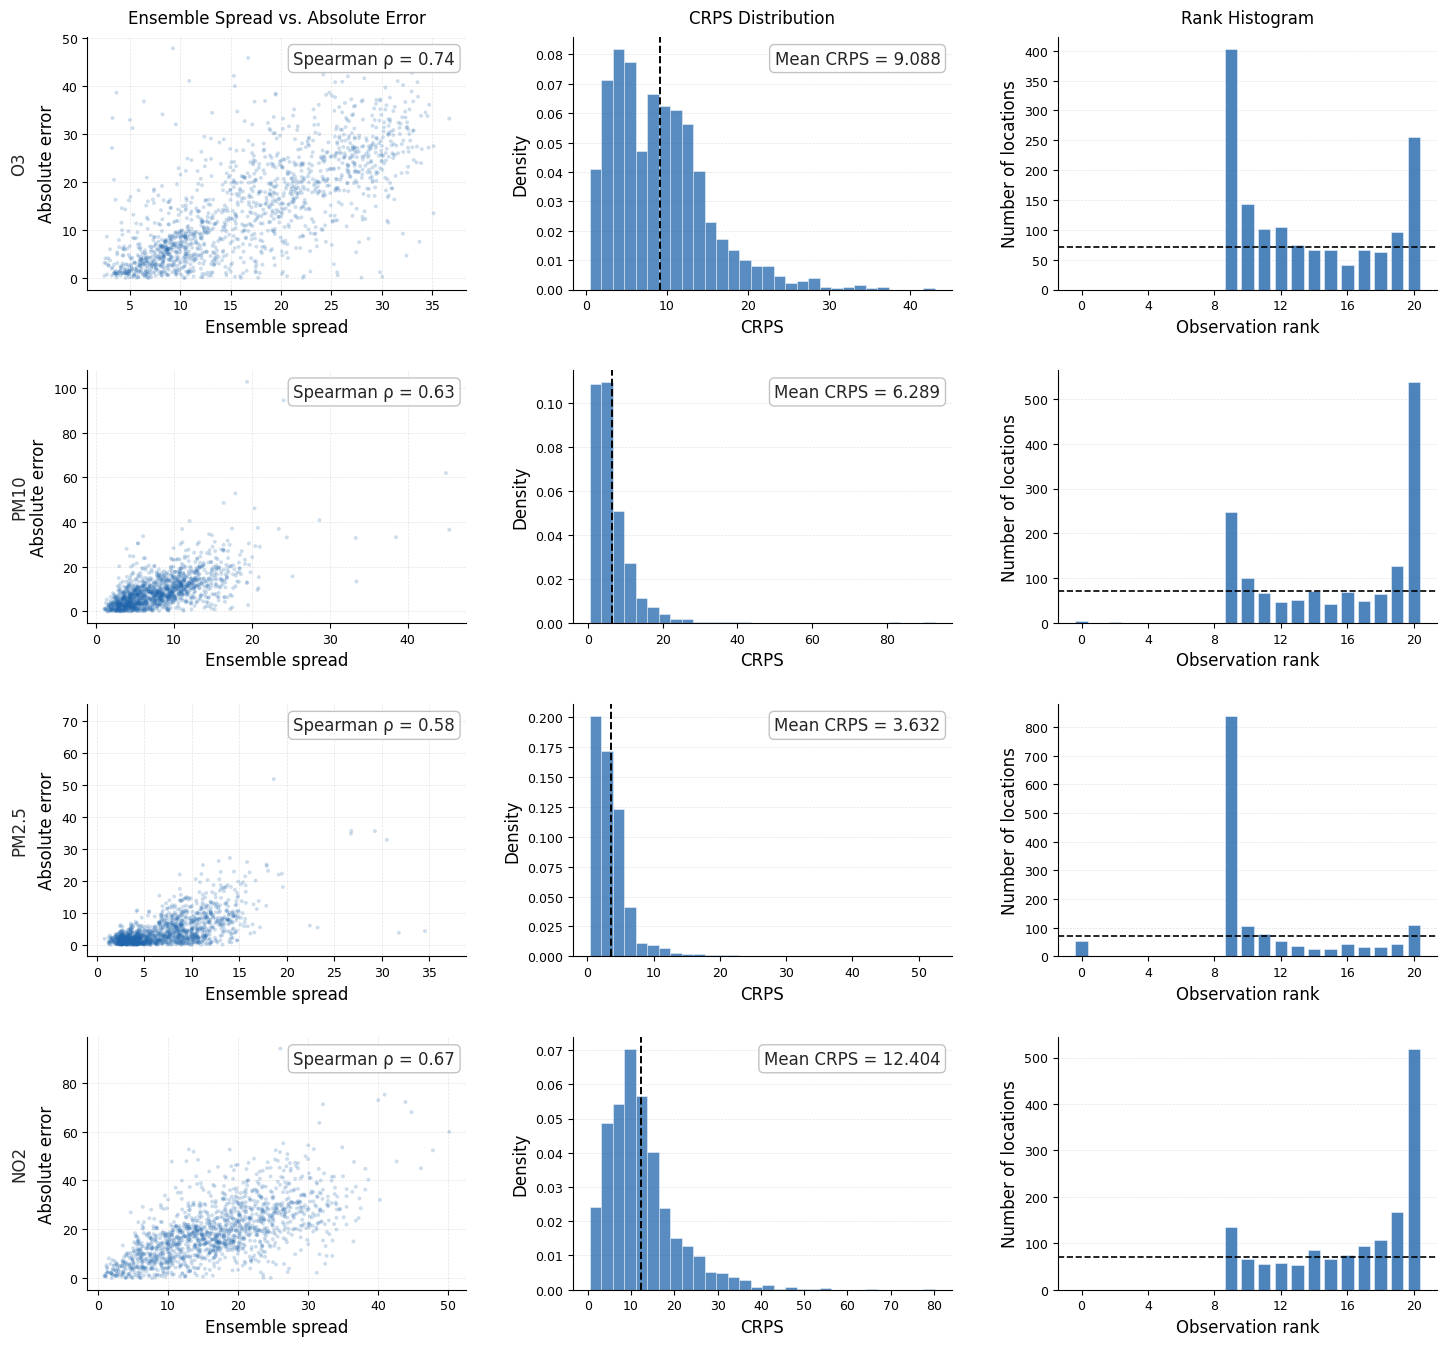

In [11]:
results = evaluate_by_pollutant(
    ground_truth,
    pred,
    target_mask,
    dir_save="paper_images/uq_vunet.png",
    pollutant_names=[
        "O3",
        "PM10",
        "PM2.5",
        "NO2"
    ]
)